# DBSCAN: Density-Based Clustering for Wholesale Client Segmentation

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies clusters as regions of high point density separated by regions of low point density.

Unlike K-Means, which assumes clusters are spherical and forces every point into a group, DBSCAN recognizes that real-world data is often messy. It categorizes points into three types:

Core Points: Dense centers of a cluster.

Border Points: On the edge of a cluster but close enough to stay.

Noise Points: Outliers that don't belong to any group (labeled as -1).

# Theoretical Framework

A point p is considered a core point if at least min_samples are within a distance ϵ of it. This neighborhood is defined as:

$N_\epsilon(p) = \{q \in D \mid \text{dist}(p, q) \le \epsilon\}$

If a point is in the neighborhood of a core point but doesn't have enough neighbors of its own to be a core point, it is a border point. If it is neither, it is noise.

# Implementation on Wholesale Spending Data

I will use a dataset of 440 wholesale clients to group them based on their annual spending across six product categories (Fresh, Milk, Grocery, Frozen, Detergents/Paper, and Delicassen).

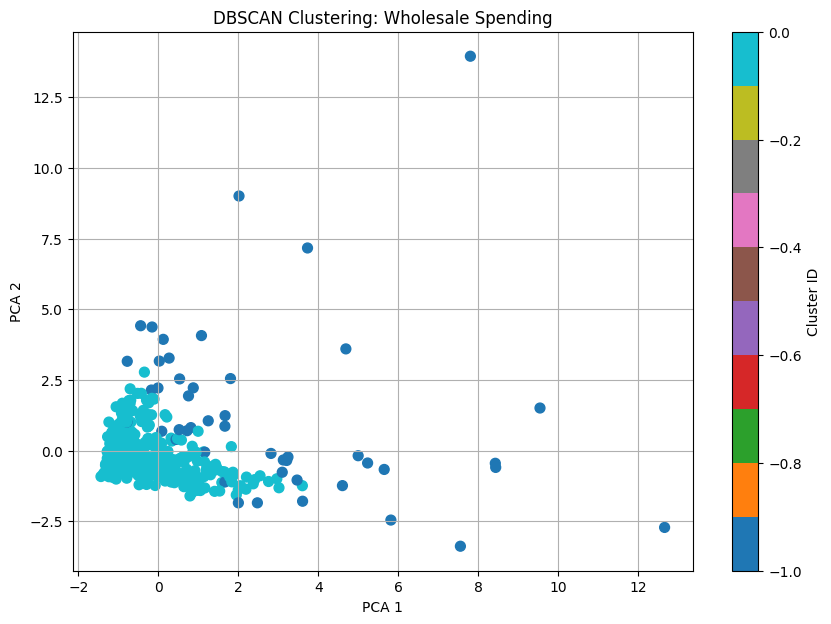

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Load the Data
# Using the Wholesale Customers dataset from UCI/Kaggle
df = pd.read_csv("Wholesale customers data.csv")

# Drop categorical columns for clustering
features = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X = df[features]

# 2. Preprocessing
# We use StandardScaler to ensure features with large ranges (like Fresh)
# don't overwhelm features with smaller ranges (like Delicassen).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply DBSCAN
# We set eps=1.0 and min_samples=5 to find dense spending groups
db = DBSCAN(eps=1.0, min_samples=5)
labels = db.fit_predict(X_scaled)
df["Cluster"] = labels

# 4. Visualize clusters using PCA
# We reduce 6D data to 2D to see the density-based groupings
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=50)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DBSCAN Clustering: Wholesale Spending")
plt.grid(True)
plt.colorbar(label="Cluster ID")
plt.show()

In [22]:
# Show the mean spending for each cluster
cluster_means = df.groupby("Cluster")[features].mean()
print(cluster_means)

                Fresh         Milk       Grocery       Frozen  \
Cluster                                                         
-1       22343.021277  17870.06383  21860.617021  8021.276596   
 0       10763.381679   4352.32570   6287.819338  2480.025445   

         Detergents_Paper   Delicassen  
Cluster                                 
-1            8542.723404  5028.340426  
 0            2204.450382  1105.880407  


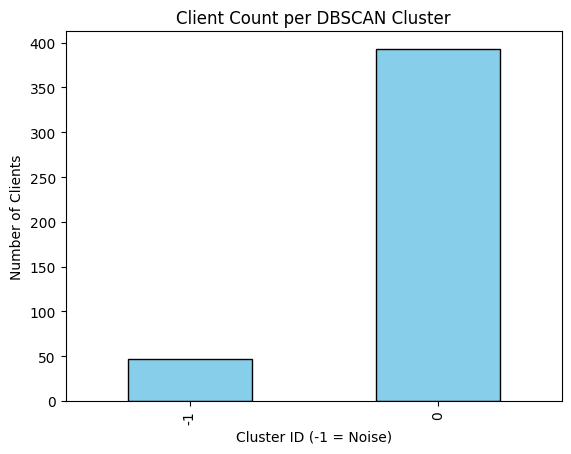

In [23]:
# Bar chart of cluster counts
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel("Cluster ID (-1 = Noise)")
plt.ylabel("Number of Clients")
plt.title("Client Count per DBSCAN Cluster")
plt.show()

Tuning the Model:

Setting eps=1.5 and min_samples=5. In wholesale data, spending varies wildly, so a slightly larger epsilon helps capture the primary "bulk" of standard clients.

In [24]:
# Apply DBSCAN
db = DBSCAN(eps=1.0, min_samples=5)
labels = db.fit_predict(X_scaled)
df['Cluster'] = labels

# Analyze results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(labels):.2%})")

Number of clusters found: 1
Number of noise points: 47 (10.68%)


Dimensionality Reduction and Visualization:

To see our 6D spending data in 2D, we use PCA. This allows us to verify if our density-based clusters actually look "crowded" in space.

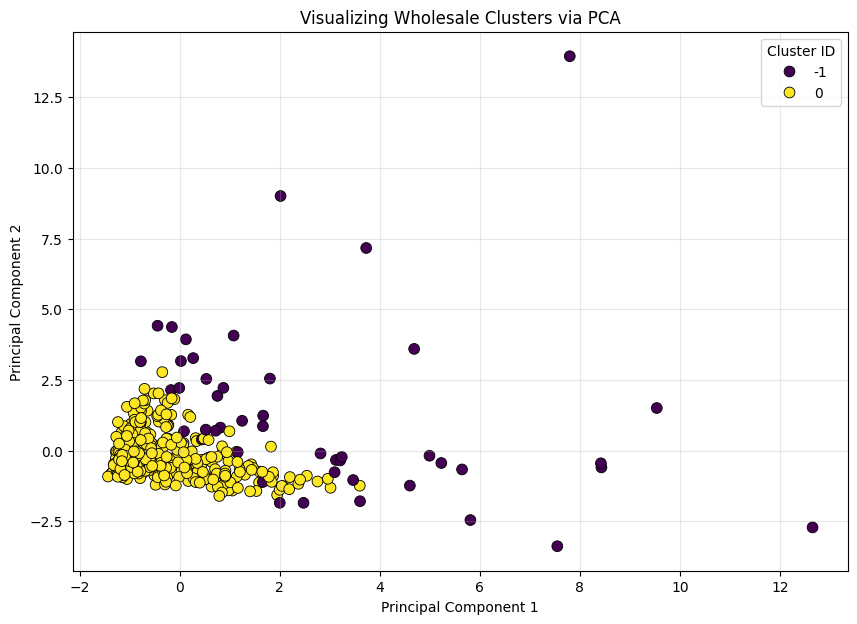

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis', s=60, edgecolor='black')
plt.title("Visualizing Wholesale Clusters via PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster ID")
plt.grid(True, alpha=0.3)
plt.show()

Evaluation and Interpretation:

## The Silhouette Score

The Silhouette Score measures how well-separated the clusters are. For DBSCAN, we only calculate this for the points that were actually assigned to a cluster (excluding the -1 noise).

The formula for the silhouette score of a point i is:
$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$


Where:

a(i): average distance from point i to other points in the same cluster.

b(i): average distance from point i to points in the nearest other cluster.

In [26]:
# Evaluate cluster quality
# We need to make sure we have at least 2 clusters (excluding noise) to calculate silhouette
unique_labels = set(labels)
if -1 in unique_labels:
    unique_labels.remove(-1)

if len(unique_labels) > 1:
    mask = df["Cluster"] != -1
    score = silhouette_score(X_scaled[mask], df["Cluster"][mask])
    print(f"Silhouette Score (no noise): {score:.3f}")
else:
    print("Silhouette Score: Not enough clusters found to calculate (need at least 2).")

# Calculate noise ratio
noise_ratio = (df['Cluster'] == -1).mean()
print(f"Noise percentage: {noise_ratio:.2%}")

Silhouette Score: Not enough clusters found to calculate (need at least 2).
Noise percentage: 10.68%


Observing Parameter Sensitivity:

To find the best results for this specific dataset, I tested several eps values:

Low ϵ (0.5): This created an extremely high noise percentage (over 80%). The density requirements were too strict for the natural variance in wholesale spending.

High ϵ (2.5): This caused nearly the entire dataset to merge into one giant cluster, failing to distinguish between different types of businesses (e.g., small cafes vs. large hotels).

Final Choice (ϵ=1.0): This value successfully identified a primary core of "Standard" businesses while correctly flagging the massive "Whale" accounts as outliers.

 DBSCAN isolates these extremes as noise, ensuring our understanding of the typicalcustomer remains clean and actionable.